Start van logboek

Om de resonantiefrequentie van de draad te meten plukken we met onze vinger aan de draad en lezen dan uit de foerier transform de freqentie af. Hieronder is de eerste plot van de golf die ontstaat door de pluk. De maximale peak to peak die is gemeten is 0.35V, we hebben de trigger op 0.1V peak to peak gezet. 

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

<class 'pandas.core.frame.DataFrame'>
           Time   Voltage
0       -9.9432 -0.001042
1       -9.9431 -0.000625
2       -9.9430 -0.000417
3       -9.9429 -0.000625
4       -9.9428 -0.001042
...         ...       ...
199995  10.0563 -0.000625
199996  10.0564 -0.000417
199997  10.0565 -0.000833
199998  10.0566 -0.000625
199999  10.0567 -0.000833

[200000 rows x 2 columns]


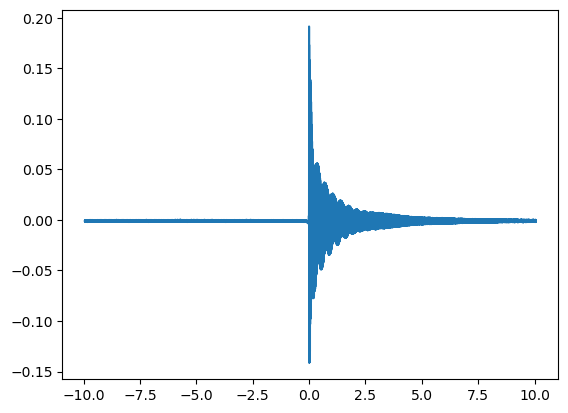

In [15]:

df = pd.read_csv("Experiment1.csv", skiprows=12, names=["Time", "Voltage"])
print(type(df))
print(df)
plt.plot(df["Time"],df["Voltage"])

We gaan de frequentieveranderingen meten bij verschillende lengtes van de draad. Om de lengte van de draad te veranderen worden de dempers aan de linker en rechter kant verder en minder ver van elkaar geplaatst. Soms hebben we ook de functiegenerator verplaatst om plek te maken voor de standaardjes.\\

In het experiment wordt de spanning op de draad benaderd met behulp van op het internet te vinden data over staal. Hierbij worden de diameter van de draad gemeten en meten we voor verschillende lengtes van de draad de frequentie. we komen op een trekkracht van 107 Newton

[107.46420194]


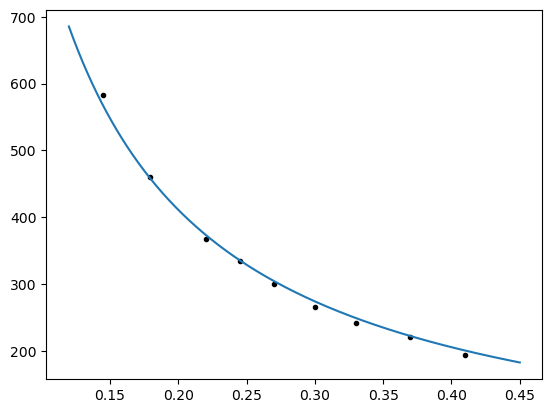

In [16]:
afs = (np.array([27.5,30,40,44,36,33,25,20.95,17.5])-3)/100
u_afs = 0.1
freq = np.array([334.9,299.7,220.3,193.7,242.5,266,367.7,461,582.4])
u_freq = 0.5
plt.plot(afs,freq,'k.')
def frequentieF(l,t):
    v = np.sqrt(t/0.003970973114137498)
    return (1*v/(2*l))
lijn = np.linspace(0.12,0.45,1000)

di = 7900 #kg/m^3
u_di = 200 #kg/m^3
r = 0.0009/2 #m 
u_r = 0.0001 #m
opp = np.pi*r**2
mu = di*opp #kg/m
popt, pcov = curve_fit(frequentieF,afs,freq)
print(popt)
plt.plot(lijn,frequentieF(lijn,*popt))

Research vraag:\
Hoe veranderd de freqentie wanneer de temperatuur van de draad veranderd


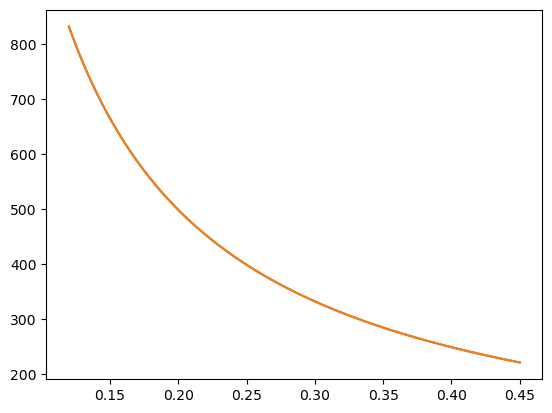

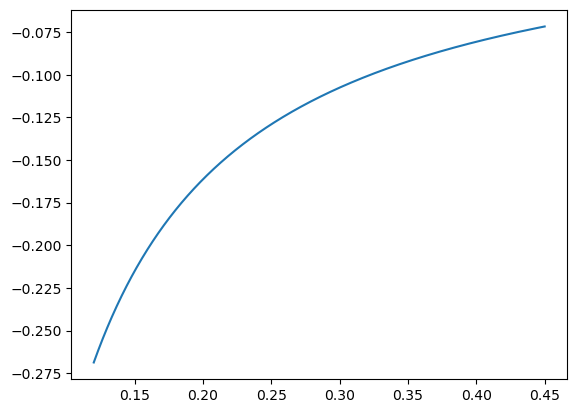

In [31]:
t=200 #N
di = 7900 #kg/m^3
r = 0.0009/2 #m 
u_r = 0.0001 #m
opp = np.pi*r**2
mu = di*opp #kg/m
afs = (np.array([27.5,30,40,44,36,33,25,20.95,17.5])-3)/100
u_afs = 0.1
freq = np.array([334.9,299.7,220.3,193.7,242.5,266,367.7,461,582.4])
u_freq = 0.5

def frequentieF(l,t,mu):
    v = np.sqrt(t/mu)
    return (1*v/(2*l))
lijn = np.linspace(0.12,0.45,1000)


alpha_V = 32.4*(10**-6) #Thermal expansion coefficient in respect to volume K^-1
alpha_L = 10.8*(10**-6)  #Thermal expansion coefficient in respect to length K^-1
V = 1
deltaT=60
delta_r = r*deltaT*alpha_L
new_r = r + delta_r
new_opp = np.pi*new_r**2
V_change = alpha_V*deltaT*V
NewV = V_change + V
New_di = di/NewV
New_mu = New_di*new_opp
change = frequentieF(lijn,t,mu) - frequentieF(lijn,t,New_mu) 

plt.plot(lijn,frequentieF(lijn,t,mu))

plt.plot(lijn,frequentieF(lijn,t,New_mu))
plt.show()
plt.plot(lijn,change)